# Introduction

Data visualisation is one the most powerful tools when communicating with data. Every data point tells a story and data visualisation helps communicate the meaning and beauty of the data. Data visualisation can also be part of the exploratory process. For instance, visualisation can help identify outliers and the data manipulation and transformations required to better present the data or build better models.

Python offers many libraries for making static or dynamic visualisations. In this notebook, we will learn foundational visualisation techniques using matplotlib, pandas, seaboard, and plotly.

In particular, the learning objectives are:
- Understaing matplotlib figures and plots;
- Customising and annotating matplotlib plots;
- Plotting different types of graphs including bar, histogram, density, boxplot, and scatter plots;
- Plotting using plotly, another Python library for advanced and interactive data visualisation.





# Visualisation with matplotlib

## What is matplotlib?

`matplotlib` is a Python plotting library for creating two dimensional graphs. It was initially developed to enable a MATLAB-like plotting interface in Python. Since then it grown an active development community to simplify interactive plotting from Jupyter notebook. 

To enable interactive plotting in Jupyter notebook, execute the following command in a cell.

In [2]:
%matplotlib inline

To import matplotlib run the following lines of code:

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

## Perth Metro Monthly Rainfall Dataset

The monthly rainfall data (included with this notebook) is the total of all available daily rainfall for the month, from 1993 to 2021. Observations of daily rainfall are nominally made at 9 am local clock time and record the total for the previous 24 hours. Rainfall includes all forms of precipiation that reach the ground, such as rain, drizzle, hail and snow.

**Data File Format**

**Column, Explanation**  
 1, 		Product code  
 2,		Bureau of Meteorology station number  
 3,		Year  
 4,	Month  
 5,		Monthly rainfall (millimetres)  
 6,		Quality of monthly rainfall  


The data is obtained from the Bureau of Meteorology website: http://www.bom.gov.au/jsp/ncc/cdio/weatherData/av?p_nccObsCode=139&p_display_type=dataFile&p_startYear=&p_c=&p_stn_num=009225

## Data wrangling with pandas

The `read_csv()` function can be used to read data file from disk into a `pandas` DataFrame.

In [ ]:
rainfall_perth = pd.read_csv("https://raw.githubusercontent.com/AustralianSDAF/python-data-visualisation/main/perth-rainfall-data.csv")

The `.head()` method can be used to print the first five rows. To view more than five rows of the DataFrame, pass a integer value to the `.head()` function.

In [8]:
#print first 50 rows
rainfall_perth.head(50) 

,Product code,Station number,Year,Month,Monthly Precipitation Total (millimetres),Quality
0,IDCJAC0001,9225,1993,2,27.6,Y
1,IDCJAC0001,9225,1993,3,5.8,Y
2,IDCJAC0001,9225,1993,4,14.6,Y
3,IDCJAC0001,9225,1993,5,129.6,Y
4,IDCJAC0001,9225,1993,6,64.4,Y
5,IDCJAC0001,9225,1993,7,123.2,Y
6,IDCJAC0001,9225,1993,8,158.4,Y
7,IDCJAC0001,9225,1993,9,82.7,Y
8,IDCJAC0001,9225,1993,11,7.0,Y
9,IDCJAC0001,9225,1993,12,2.4,Y


In [17]:
# Select all rows of the column 'Monthly Precipitation Total (millimetres)' and store it in a pandas Series
precip = rainfall_perth["Monthly Precipitation Total (millimetres)"]
precip

0       27.6
1        5.8
2       14.6
3      129.6
4       64.4
       ...  
336     40.6
337    113.6
338     93.6
339    271.4
340     56.6
Name: Monthly Precipitation Total (millimetres), Length: 341, dtype: float64

In the above example, `precip` is a pandas Series. The index for this Series is displayed on the left (column 1) and the values (total precipitation) are displayed on the right (column 2).

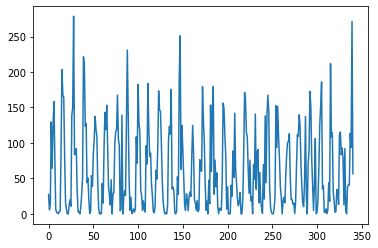

In [16]:
# Plot "total precipitation" (y) versus the index (x) as lines and/or markers.
plt.plot(precip)

## Figures and subplots

A `Figure` object is the outermost container for a matplotlib graphic. Plots in matplotlib sit within a `Figure` object.   
   
You can create a new figure with `plt.figure()`:

In [7]:
fig = plt.figure()

<Figure size 432x288 with 0 Axes>

Before you can make plots in a figure, you have to create one or more subplots using `add_subplot`:

In [8]:
ax1 = fig.add_subplot(2, 2, 1)

The above code creates a grid of 2 rows and 2 columns (four plots in total), where `ax1` is the first of the four subplots.

To create two more subplots, you run the following code. The objects returned by `fig.add_subplot` here are `AxesSubplot` objects. You can directly plot on the other empty subplots by calling each one’s instance method

In [9]:
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

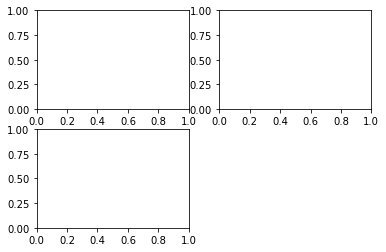

In [10]:
# After creating three subplots on a 2x3 grid, the figure looks like this.
fig

The code below plots a histogram of the `Monthly Precipitation Total (millimetres)` on subplot1.

In [11]:
ax1.hist(precip, bins=20)

(array([94., 48., 31., 24., 16., 16., 22., 16., 21., 10., 17.,  5.,  9.,
         4.,  1.,  3.,  1.,  0.,  1.,  2.]),
 array([  0.  ,  13.93,  27.86,  41.79,  55.72,  69.65,  83.58,  97.51,
        111.44, 125.37, 139.3 , 153.23, 167.16, 181.09, 195.02, 208.95,
        222.88, 236.81, 250.74, 264.67, 278.6 ]),
 <BarContainer object of 20 artists>)

The code below plots a scatter plot, where x is the `Year` column and y is `Monthly Precipitation Total (millimetres)`, on subplot2.

In [12]:
ax2.scatter(rainfall_perth.iloc[:, 2], precip)

In [13]:
# this plots the the total precipitation on the y, and the index of the pandas Series on the x axis.
ax3.plot(precip)

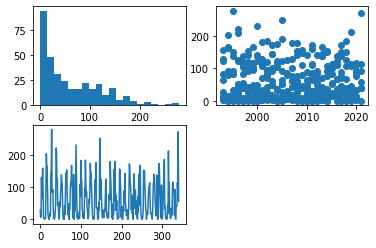

In [14]:
fig

## Customising plots

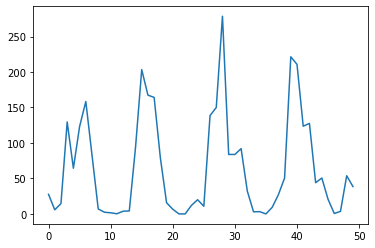

In [15]:
# Plot the first 50 rows of the `precip` Series
plt.plot(precip[:50])

Matplotlib's main plot function accepts a string abbreviation indicating color and line style. For instance, to plot the `Monthly Precipitation Total (millimetres)` using green dashes and green markers that highlight the actual data point, the 'go--' abbreviation can be used.

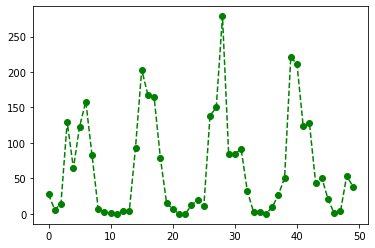

In [16]:
plt.plot(precip[:50], 'go--')

The above style can also be expressed more explicitly as such:

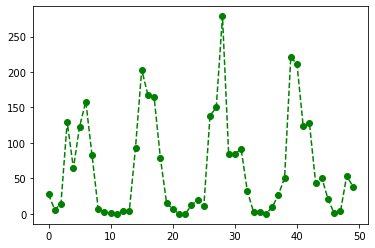

In [17]:
plt.plot(precip[:50], linestyle='--', color='g', marker='o')

### Labels, Legends, and Ticks

Legends are an important element of plots and visualisations. In matplotlib, the easiest way to develop build a legend is to pass the `label` argument when adding each piece of the plot:

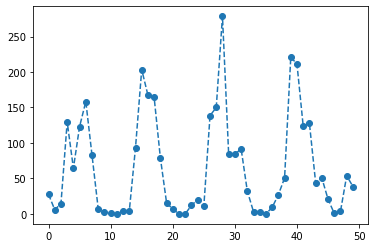

In [18]:
plt.plot(precip[:50], linestyle='--', marker='o', label='rainfall')

To add the legend to a plot, simply call the `legend()` function.

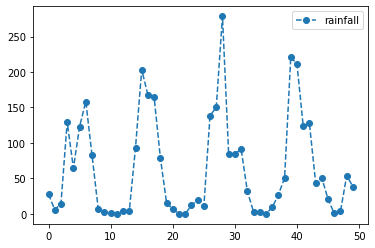

In [19]:
fig = plt.figure() #instantitate a Figure object
ax = fig.add_subplot(1,1,1) #add a 1x1 subplot
ax.plot(precip[:50], linestyle='--', marker='o', label='rainfall') #plot the first 50 points with the dash and marker linestyle, and include a rainfall label
ax.legend(loc='best') # place a legend on the subplot on the upper right of the figure

To change the x-axis ticks, it’s easiest to use `set_xticks` and `set_xticklabels`.   
   
The `set_xticks` tells matplotlib where to place the ticks along the data range. The `set_xticklabels` allows us to set other values as the x labels of the plot.

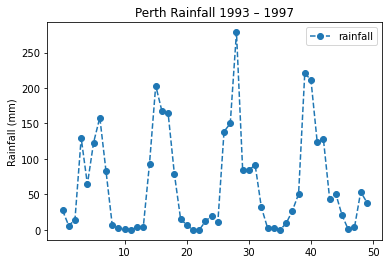

In [20]:
ax.set_xticks([10,20,30,40,50]) #sets the x ticks at 10, 20, 30, 40, and 50
ax.set_title('Perth Rainfall 1993 – 1997') # Sets the title of the plot
ax.set_ylabel("Rainfall (mm)") # Sets the y label
fig

### Multiple line plots

In the following cells we are going to combine everything we have learned so far to plot and compare the total rainfall for the years 2010 and 2020.

First, we need get the 2010 rainfall data from the `rainfall_perth` DataFrame and store it in a new variable.

In [21]:
# Filter data where year is 2010 and retrieve only the 3rd and 4th column.
perth_rainfall_2010 = rainfall_perth[rainfall_perth['Year'] == 2010].iloc[:, 3:5]

#Reset the index of the DataFrame, and use the default one instead.
perth_rainfall_2010.reset_index(drop=True)

,Month,Monthly Precipitation Total (millimetres)
0,1,0.0
1,2,0.2
2,3,40.4
3,4,25.0
4,5,88.6
5,6,51.4
6,7,142.0
7,8,63.0
8,9,43.6
9,10,20.6


Then we need get the 2020 rainfall data from the `rainfall_perth` DataFrame and store it in a new variable. Here we use the `iloc` indexing operation to select only the fourth (index 3) and the fifth (index fourth) column (Monthly Precipitation Total (millimetres)).

In [22]:
perth_rainfall_2020 = rainfall_perth[rainfall_perth['Year'] == 2020].iloc[:, 3:5]
perth_rainfall_2020.reset_index(drop=True)

,Month,Monthly Precipitation Total (millimetres)
0,1,3.0
1,2,34.4
2,3,32.8
3,4,13.2
4,5,111.6
5,6,115.4
6,7,83.4
7,8,92.8
8,9,77.8
9,10,12.6


Text(0.5, 1.0, 'Perth Rainfall 2010 vs. 2020')

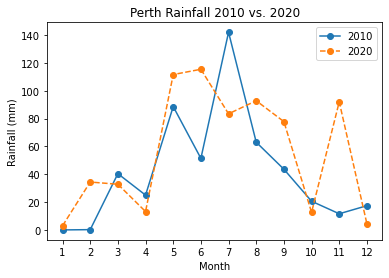

In [23]:
fig= plt.figure() #instantiate a figure
ax = fig.add_subplot(1,1,1) #add a subplot

#plot Month (x) against rainfall (y) for the year 2010
ax.plot(perth_rainfall_2010['Month'], perth_rainfall_2010['Monthly Precipitation Total (millimetres)'], linestyle='-', marker='o', label='2010')

#plot Month (x) against rainfall (y) for the year 2020
ax.plot(perth_rainfall_2020['Month'], perth_rainfall_2020['Monthly Precipitation Total (millimetres)'], linestyle='--', marker='o', label='2020')

#set the xticks to include every month of the year
ax.set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])

#Place the legend on the top right corner
ax.legend(loc='best')

# Set the xlabel to Month
ax.set_xlabel('Month')

# Set the ylabel to Rainfall (mm)
ax.set_ylabel('Rainfall (mm)')

#Set the title of the plot
ax.set_title('Perth Rainfall 2010 vs. 2020')

## Exporting plots

The `savefig()` function can be used to the save a figure to file. To save a PNG version of a figure, you run the following:

In [24]:
fig.savefig("Perth_1993_1994_Rainfall.png", dpi=400, bbox_inches='tight')

Matplotlib automatically infers the file type from the file extension. For instance, if the file extension is `.pdf`, then matplotlib will save the figure as a PDF.   
   
The `.savefig()` function offers a number of parameters for publishing graphics.   
The `dpi` or the dots-per-inch parameter specifies the output resolution of the figure. The higher the dpi, the higher the resolution of the figure (higher the file size)   
The `bbox_inches` parameter trims the whitespace around the figure and outputs a figure with minimal whitespace around the plot.

## Configuring matplotlib

Matplotlib comes pre-configured with color schemes and settings that are primarily aimed at preparing figures for publication. However, allmost all of the default settings can be customised to your preferences and needs.   
   
One way to modify the configuration programmatically from Python is to use the `rc` method. For instance, to set the global default figure size to be 10x10, the following command can be used:

In [25]:
plt.rc('figure', figsize=(10,10))

The first argument in the `.rc()` function is the component you would like to customise (e.g., figure, axes, grid, xticks). This is then followed by a series of keyword arguments specifying the new parameters (e.g., font size, font family, font weight, etc.).   
   
An easy way to write down the options in your program is as a dict:

In [26]:
# font_options = {'family' : 'monospace','weight' : 'bold','size' :8} 
# plt.rc('font', **font_options)

For more extensive customization and to see a list of all the options, matplotlib comes with a configuration file, `matplotlibrc`, in the `matplotlib/mpl-data` directory. If you customize this file and place it in your home directory titled `.matplotlibrc`, it will be loaded each time you use matplotlib.

# Visualisation with pandas

Matplotlib can be a low-level tool and doing sophisticated statistical visualization can require a lot of repetitive code. In pandas we often deal with multiple columns of data, along with row and column labels. pandas itself comes with built-in methods that simplify creating visualisations from DataFrame and Series objects.   
   
In the following section, we will discuss some data visualisation techniques using pandas.

## Line plot

Pandas `Series` and `DataFrame` have a `plot()` function for generating basic plot types. By default, the `plot()` generate line plots.

The `groupby()` splits the data contained in a pandas object (i.e., Series, DataFrame) into groups based on one or more keys that you provide. In the following example, the `rainfall_perth` data is grouped by the `Year` key. Once this is done, the `sum()` is applied to each group, producing a new value. In this case, the value we are interested in is the total rainfall for each year. Note that this operation also sums the values in the other columns of the DataFrame. However, in this case we are not interested in those values.

In [27]:
rainfall_by_year = rainfall_perth.groupby(['Year']).sum()
rainfall_by_year

,Station number,Month,Monthly Precipitation Total (millimetres)
Year,,,
1993,92250,67,615.7
1994,110700,78,739.8
1995,110700,78,904.8
1996,110700,78,888.6
1997,110700,78,699.4
1998,110700,78,742.6
1999,110700,78,822.0
2000,110700,78,796.2
2001,110700,78,688.6


Pandas `plot()` function plots each of its columns as a different line on the same subplot. Here we are only interested in the `Monthly Precipitation Total` column.

<AxesSubplot:title={'center':'Rainfall in Perth'}, xlabel='Year', ylabel='Rainfall (mm)'>

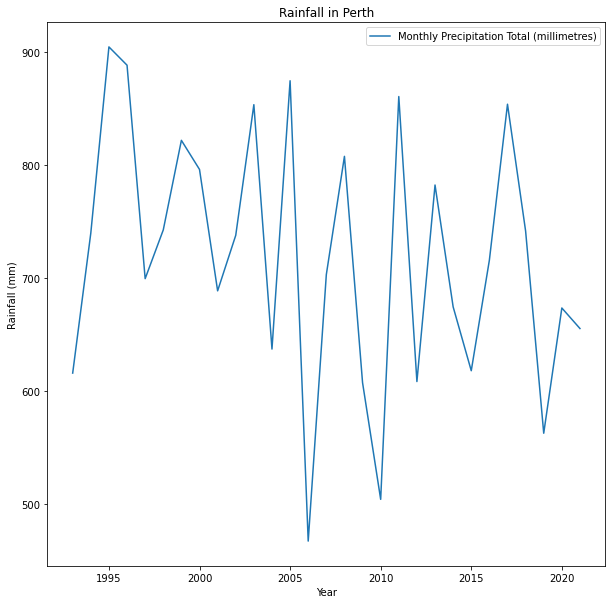

In [28]:
rainfall_by_year['Monthly Precipitation Total (millimetres)'].plot(title="Rainfall in Perth", ylabel="Rainfall (mm)", legend=True)

## Bar plot

The plot() functions contains a “family” of fuctions for different plot types. For example, `rainfall_by_year.plot()`, in the above examples, is equivalent to `rainfall_by_year.plot.line()`.

In [29]:
rainfall_perth.head()

,Product code,Station number,Year,Month,Monthly Precipitation Total (millimetres),Quality
0,IDCJAC0001,9225,1993,2,27.6,Y
1,IDCJAC0001,9225,1993,3,5.8,Y
2,IDCJAC0001,9225,1993,4,14.6,Y
3,IDCJAC0001,9225,1993,5,129.6,Y
4,IDCJAC0001,9225,1993,6,64.4,Y


In [30]:
# Drop the "Product code", "Station number", "Quality" columns because we do not need them.
rainfall_perth.drop(["Product code", "Station number", "Quality" ], axis=1, inplace=True)

In [31]:
#Group the data by Month and compute the total rainfall for each month
temp = rainfall_perth.groupby(['Month']).sum()

In [32]:
temp.head()

,Year,Monthly Precipitation Total (millimetres)
Month,,
1,56210,516.6
2,58203,414.0
3,58203,593.0
4,58203,1025.8
5,58203,2568.6


The `plot.bar()` and `plot.barh()` make vertical and horizontal bar plots, respectively. In the following example, the Series or DataFrame index will be used as the x values, and the `Monthly Precipitation Total (millimetres)` will be used as the y values.

<AxesSubplot:title={'center':'Rainfall by Month'}, xlabel='Month', ylabel='Rainfall (mm)'>

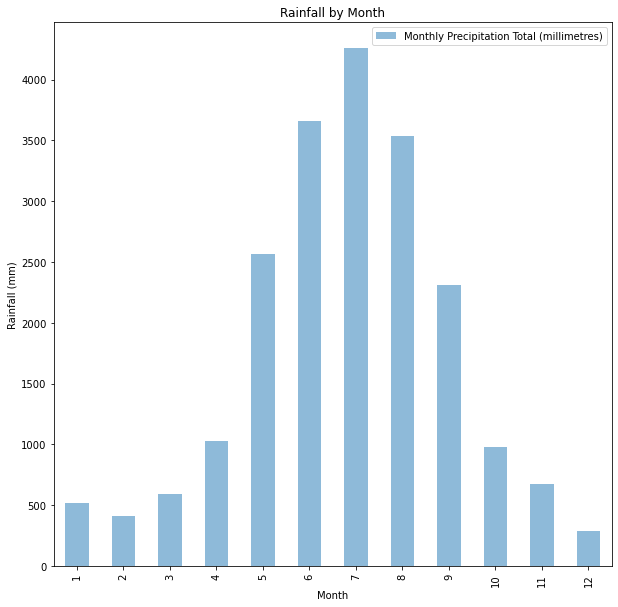

In [33]:
temp.plot.bar(y='Monthly Precipitation Total (millimetres)',ylabel="Rainfall (mm)", alpha=0.5, title="Rainfall by Month")

Below, we group the `rainfall_perth` DataFrame by year and calculate the total rainfall for the whole year.   
   
The`plot.barh()` function makes a horizontal bar plot. Here, the Series or DataFrame index, which is the year, will be used as the y values, and the sum of the `Monthly Precipitation Total (millimetres)` for each year will be used as the x values.

<AxesSubplot:ylabel='Year'>

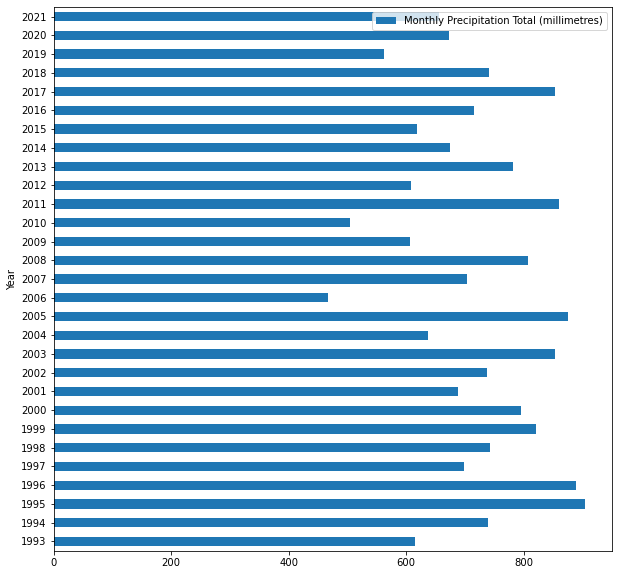

In [34]:
groupYear = rainfall_perth.groupby(['Year']).sum()
groupYear.plot.barh(y='Monthly Precipitation Total (millimetres)')

## Boxplot

A box plot is a method for graphically depicting groups of numerical data through their quartiles. The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of box to show the range (min and max) of the data.   
   
The `plot.box()` method can be used to make a box plot of a DataFrame.

<AxesSubplot:title={'center':'Rainfall in Perth'}>

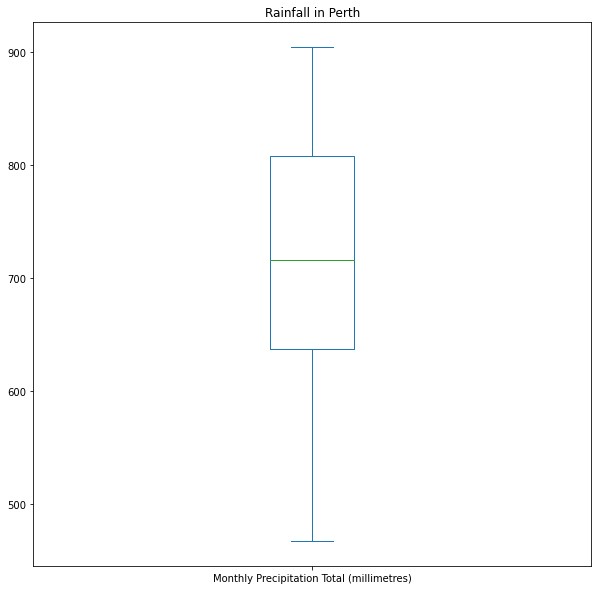

In [35]:
#Group the rainfall data by year and the calculate the total rainfall for each year.
rainfall_by_year = rainfall_perth.groupby(['Year']).sum()

#Make a box plot of the 'Monthly Precipitation Total (millimetres)' column, with legend and plot title.
rainfall_by_year['Monthly Precipitation Total (millimetres)'].plot.box(title="Rainfall in Perth", legend=True)

The `vert=False` parameter can be used to make a horizontal box plot as such:

<AxesSubplot:title={'center':'Rainfall in Perth'}>

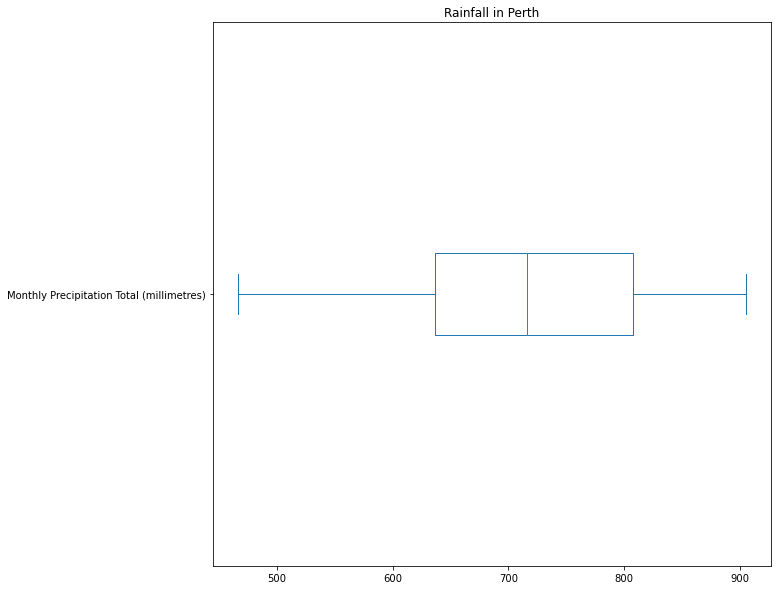

In [36]:
rainfall_by_year['Monthly Precipitation Total (millimetres)'].plot.box(title="Rainfall in Perth", legend=True, vert=False)

## Scatter plot

Scatter plots are very useful to see complex correlations between two variables.   
    
The `plot.scatter()` function is used to make scatter plots. The coordinates of each point are defined by two dataframe columns and filled circles are used to represent each point.   
   
In the following example, the 'Year' is used in the x-axis, and the sum of 'Monthly Precipitation Total (millimetres)' for each year in the y-axis.

<AxesSubplot:title={'center':'Rainfall in Perth'}, xlabel='Year', ylabel='Monthly Precipitation Total (millimetres)'>

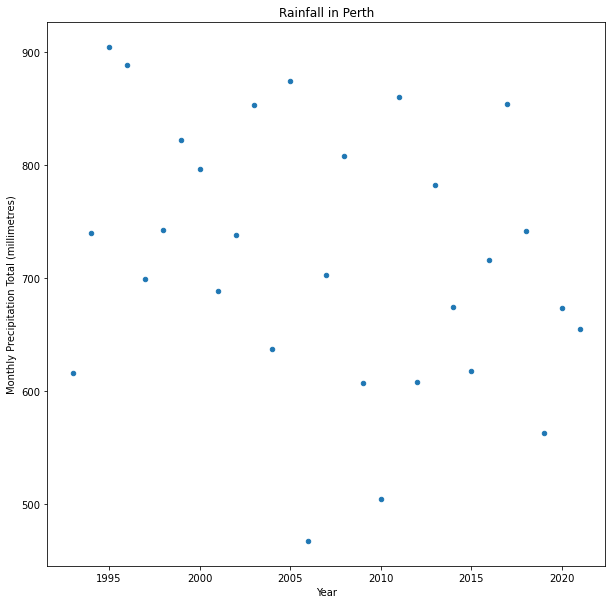

In [37]:
rainfall_by_year.reset_index().plot.scatter(x='Year', y='Monthly Precipitation Total (millimetres)',title="Rainfall in Perth", legend=True)